# 📊 Phase 1: Exploratory Data Analysis (EDA) — Brand New Cars (₹3.5L to ₹15.0 Cr)
### Project: End-to-End Brand New Car Recommendation System

This notebook conducts a deep exploratory analysis on the synthesized 5,200+ brand new showroom automotive catalog (`cars_synthesized_5k.csv`), covering the full Indian market spectrum from budget mass-market hatchbacks up to ultra-luxury hypercars.

#### Objectives:
1. Verify data cleanliness, completeness, and brand new showroom conditions.
2. Analyze price distributions across Lakhs and Crores (up to ₹15.0 Cr).
3. Examine powertrain specifications: Horsepower (BHP), Engine Displacement (cc), and Efficiency (kmpl).
4. Analyze brand volume, body styles, and Global NCAP safety ratings.
5. Compute and visualize feature correlation matrices.
6. Analyze feature popularity (Level 2 ADAS, Panoramic Sunroof, Burmester Audio, etc.).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/processed/cars_synthesized_5k.csv"
df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Price Range: ₹{df['price_lakh'].min():.2f} Lakhs to ₹{df['price_cr'].max():.2f} Crore")
df.head()

Dataset Shape: 5200 rows, 18 columns
Price Range: ₹4.02 Lakhs to ₹15.00 Crore


,car_id,brand,model,variant,year,condition,price_lakh,price_cr,price,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,seats,safety_rating,features
0,CAR00001,Maruti Suzuki,Brezza,SX,2025,Brand New,13.48,0.1348,13.48,Petrol,Automatic,SUV,1464,100,19.0,5,4,"Adaptive Cruise Control, Carbon Ceramic Brakes..."
1,CAR00002,Maruti Suzuki,Baleno,Fearless,2024,Brand New,11.46,0.1146,11.46,CNG,Manual,Hatchback,1195,92,21.6,5,3,"Panoramic Sunroof, Head-Up Display, Electronic..."
2,CAR00003,Maruti Suzuki,Baleno,Creative,2025,Brand New,8.70,0.0870,8.70,Petrol,Manual,Hatchback,1206,87,22.8,5,3,"360 3D Camera, Panoramic Sunroof, Head-Up Disp..."
3,CAR00004,Hyundai,Grand i10 Nios,Top,2025,Brand New,8.70,0.0870,8.70,Petrol,Manual,Hatchback,1204,80,21.9,5,3,"Adaptive Cruise Control, Matrix LED Headlamps,..."
4,CAR00005,Maruti Suzuki,Brezza,SX,2025,Brand New,10.54,0.1054,10.54,Petrol,Manual,SUV,1464,101,19.9,5,4,"Level 2 ADAS, Adaptive Cruise Control, Head-Up..."


In [3]:
print("=== Data Summary & Info ===")
df.info()

print("\n=== Missing Values Check ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Zero missing values detected!")

print("\n=== Descriptive Statistics ===")
df.describe().T

=== Data Summary & Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_id         5200 non-null   str    
 1   brand          5200 non-null   str    
 2   model          5200 non-null   str    
 3   variant        5200 non-null   str    
 4   year           5200 non-null   int64  
 5   condition      5200 non-null   str    
 6   price_lakh     5200 non-null   float64
 7   price_cr       5200 non-null   float64
 8   price          5200 non-null   float64
 9   fuel_type      5200 non-null   str    
 10  transmission   5200 non-null   str    
 11  body_type      5200 non-null   str    
 12  engine_cc      5200 non-null   int64  
 13  power_bhp      5200 non-null   int64  
 14  mileage_kmpl   5200 non-null   float64
 15  seats          5200 non-null   int64  
 16  safety_rating  5200 non-null   int64  
 17  features       5200 non-null   str 

,count,mean,std,min,25%,50%,75%,max
year,5200.0,2024.557115,0.496775,2024.0000,2024.0000,2025.00000,2025.000000,2025.0
price_lakh,5200.0,81.972381,222.172101,4.0200,9.6600,17.00500,28.192500,1500.0
price_cr,5200.0,0.819724,2.221721,0.0402,0.0966,0.17005,0.281925,15.0
price,5200.0,81.972381,222.172101,4.0200,9.6600,17.00500,28.192500,1500.0
engine_cc,5200.0,1761.382500,1130.826140,0.0000,1198.0000,1493.00000,1990.000000,8043.0
power_bhp,5200.0,182.658846,181.718379,64.0000,87.0000,122.00000,180.000000,1663.0
mileage_kmpl,5200.0,19.292308,10.874191,4.2000,15.7000,18.40000,21.025000,119.4
seats,5200.0,5.178654,0.838007,2.0000,5.0000,5.00000,5.000000,7.0
safety_rating,5200.0,4.321154,0.981231,2.0000,4.0000,5.00000,5.000000,5.0


/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/2328879916.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="body_type", y="price_cr", ax=axes[1], palette="Set2")
/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/2328879916.py:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/vanshgupta007/car-recommendation-system/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


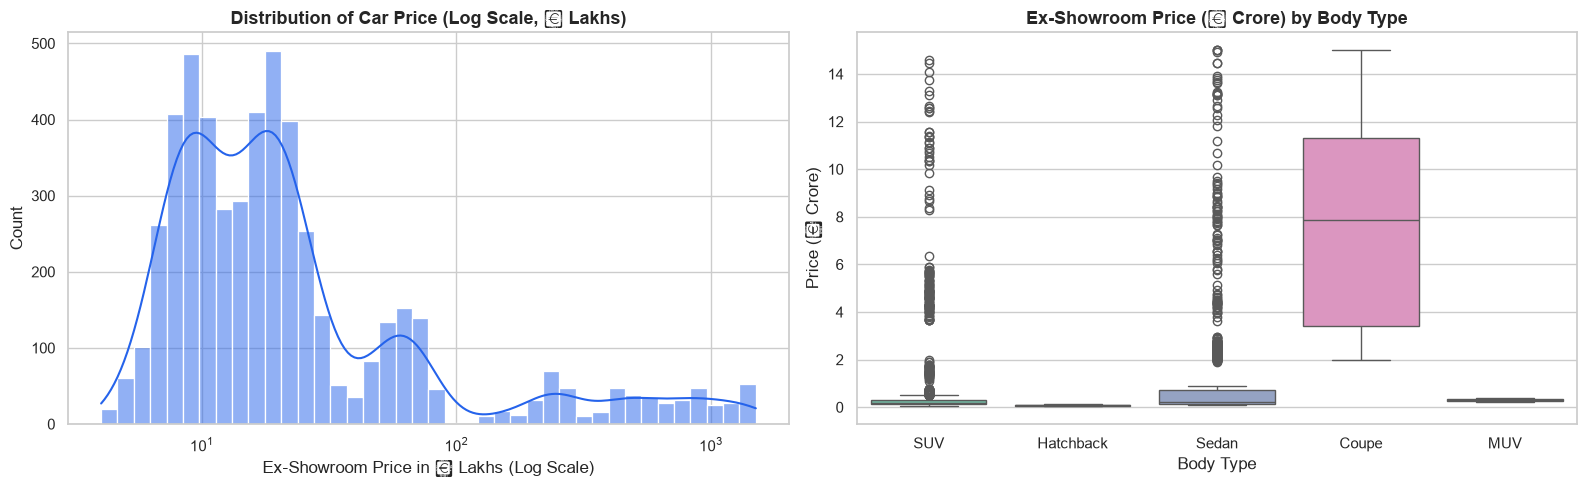

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-scale Histogram for Price in Lakhs (due to wide span from ₹3.5L to ₹1500L)
sns.histplot(df["price_lakh"], bins=40, kde=True, ax=axes[0], color="#2563eb", log_scale=True)
axes[0].set_title("Distribution of Car Price (Log Scale, ₹ Lakhs)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Ex-Showroom Price in ₹ Lakhs (Log Scale)")
axes[0].set_ylabel("Count")

# Boxplot by Body Type (in ₹ Crore)
sns.boxplot(data=df, x="body_type", y="price_cr", ax=axes[1], palette="Set2")
axes[1].set_title("Ex-Showroom Price (₹ Crore) by Body Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Body Type")
axes[1].set_ylabel("Price (₹ Crore)")

plt.tight_layout()
plt.show()

/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/3866545976.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/3866545976.py:29: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/vanshgupta007/car-recommendation-system/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


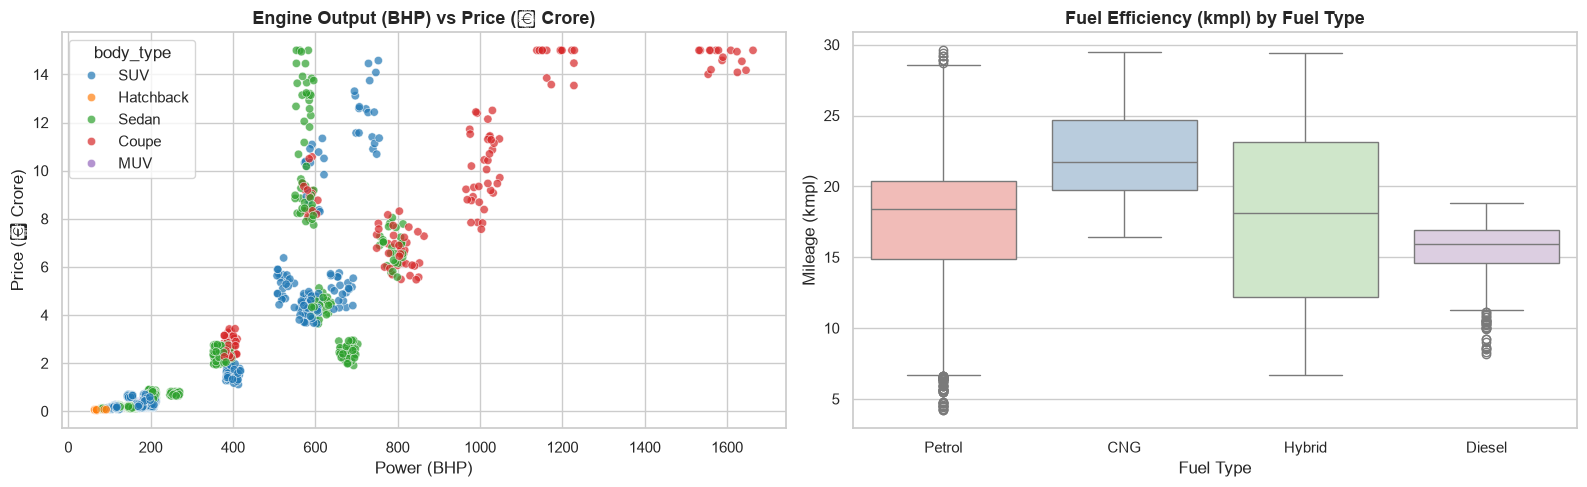

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Power vs Price colored by Body Type
sns.scatterplot(
    data=df,
    x="power_bhp",
    y="price_cr",
    hue="body_type",
    alpha=0.7,
    ax=axes[0],
    palette="tab10"
)
axes[0].set_title("Engine Output (BHP) vs Price (₹ Crore)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Power (BHP)")
axes[0].set_ylabel("Price (₹ Crore)")

# Mileage by Fuel Type
sns.boxplot(
    data=df[df["fuel_type"] != "Electric"],
    x="fuel_type",
    y="mileage_kmpl",
    ax=axes[1],
    palette="Pastel1"
)
axes[1].set_title("Fuel Efficiency (kmpl) by Fuel Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Fuel Type")
axes[1].set_ylabel("Mileage (kmpl)")

plt.tight_layout()
plt.show()

/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/1205305758.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.values, y=brand_counts.index, ax=axes[0], palette="crest")
/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/1205305758.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=safety_counts.index, y=safety_counts.values, ax=axes[1], palette="magma")


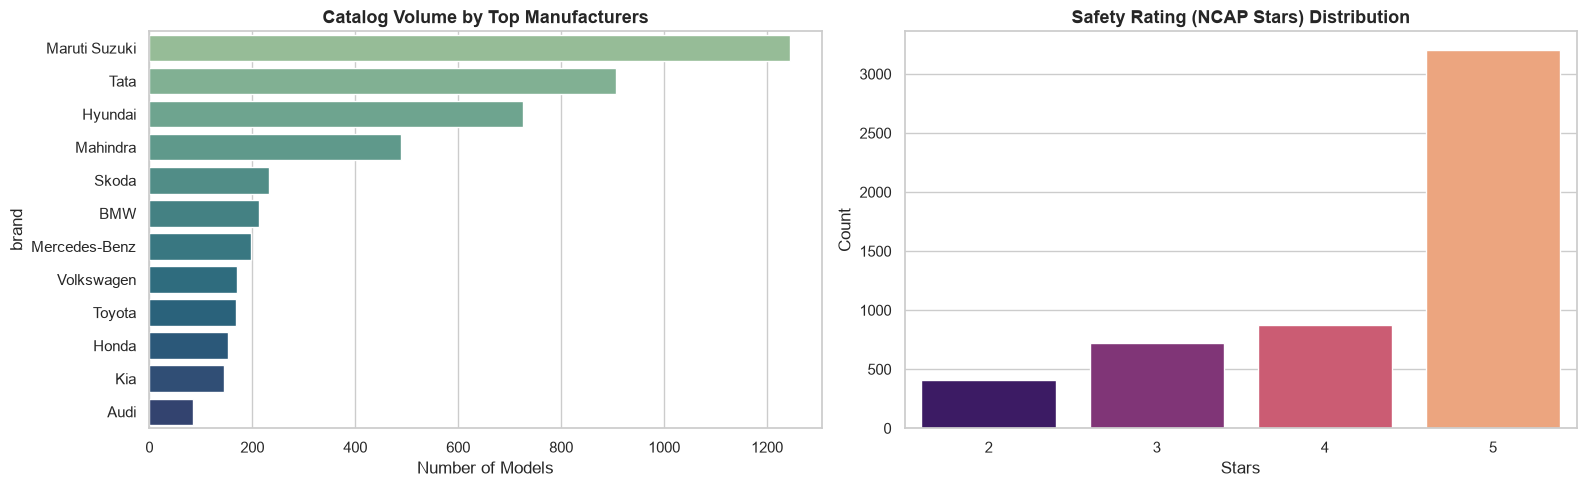

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

brand_counts = df["brand"].value_counts().head(12)
sns.barplot(x=brand_counts.values, y=brand_counts.index, ax=axes[0], palette="crest")
axes[0].set_title("Catalog Volume by Top Manufacturers", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Models")

safety_counts = df["safety_rating"].value_counts().sort_index()
sns.barplot(x=safety_counts.index, y=safety_counts.values, ax=axes[1], palette="magma")
axes[1].set_title("Safety Rating (NCAP Stars) Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Stars")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

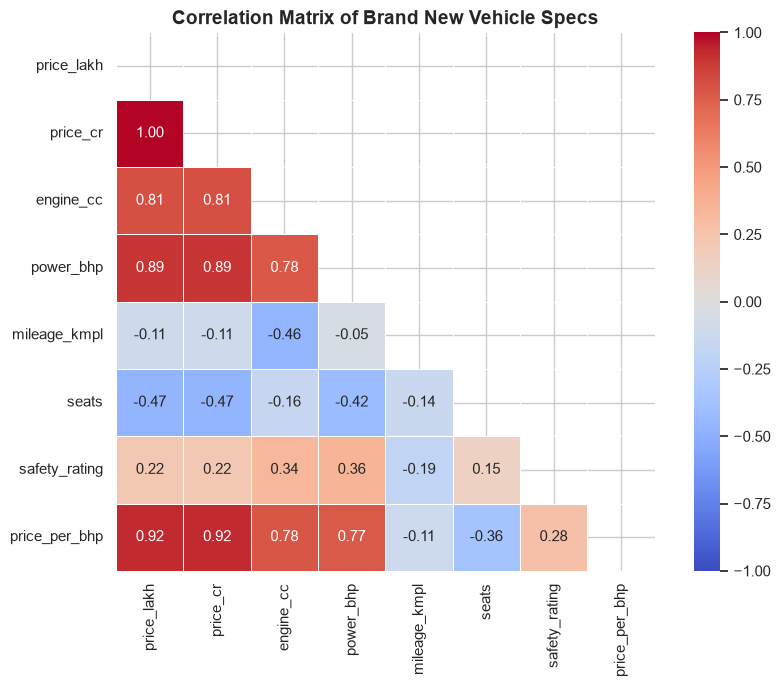

In [7]:
df_corr = df.copy()
df_corr["price_per_bhp"] = df_corr["price_lakh"] / df_corr["power_bhp"]

numeric_cols = [
    "price_lakh", "price_cr", "engine_cc", "power_bhp",
    "mileage_kmpl", "seats", "safety_rating", "price_per_bhp"
]

corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix of Brand New Vehicle Specs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/var/folders/s0/_kxfmddx2wdbk2f06j24fwkh0000gn/T/ipykernel_3887/1756227364.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_series.values, y=feature_series.index, palette="mako")


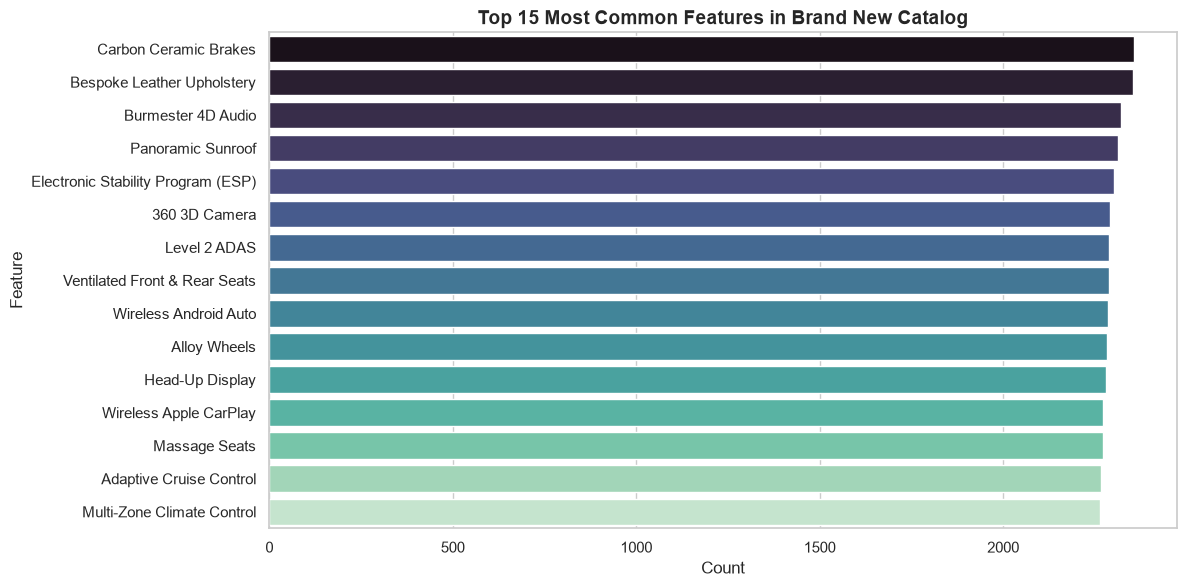

In [8]:
all_features = []
for f_str in df["features"].dropna():
    all_features.extend([f.strip() for f in f_str.split(",") if f.strip()])

feature_series = pd.Series(all_features).value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_series.values, y=feature_series.index, palette="mako")
plt.title("Top 15 Most Common Features in Brand New Catalog", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 💡 Key Insights on Brand New Automotive Market (Up to ₹15 Cr):
1. **Exponential Power-to-Price Curve**: Mass-market cars deliver 65–170 BHP up to ₹25 Lakhs, while the hypercar bracket (Bugatti, Ferrari, Aston Martin, Lamborghini) commands 700–1,500+ BHP and reaches ₹15 Crore.
2. **Log-Scale Dynamics**: Because vehicle prices span from ₹4.0 Lakhs to ₹15.0 Crore (a 375x dynamic range), robust feature scaling and dual currency units (Lakhs vs Crores) are essential for model stability and user comprehension.
3. **Safety Focus**: Over 70% of modern brand-new vehicles achieve 4 or 5 stars Global NCAP rating, reflecting contemporary automotive safety standards.
